## Lab 7: Tree Methods

#### Imports

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error
from ISLP import load_data

In [26]:
# Load Carseats data
Carseats = load_data('Carseats')
Carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


### Decision Trees

We first consider a single decision tree. A decision tree is non-parametric method to perform regression and classification defined by a tree-like, hierarchical structure parameterized by binary splits on thresholds of different x-variables. To make predictions for a classification decision tree, we take a majority vote of the training samples in any leaf (and then for test data, find the leaf node to which a test sample maps).

The following code fits a classification tree by using all features except `Sales`.

In [27]:
# Create High variable: 1 if Sales > 8, else 0
High = np.where(Carseats.Sales > 8, "Yes", "No")
X = Carseats.drop(['Sales'], axis=1)

# Convert qualitative predictors to dummy variables (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)
y = High

In [28]:
# Fit the tree
clf = DecisionTreeClassifier(max_depth=6) # Limiting depth for readability
clf.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

To visualize the fitted classification tree, you can use the following code. 

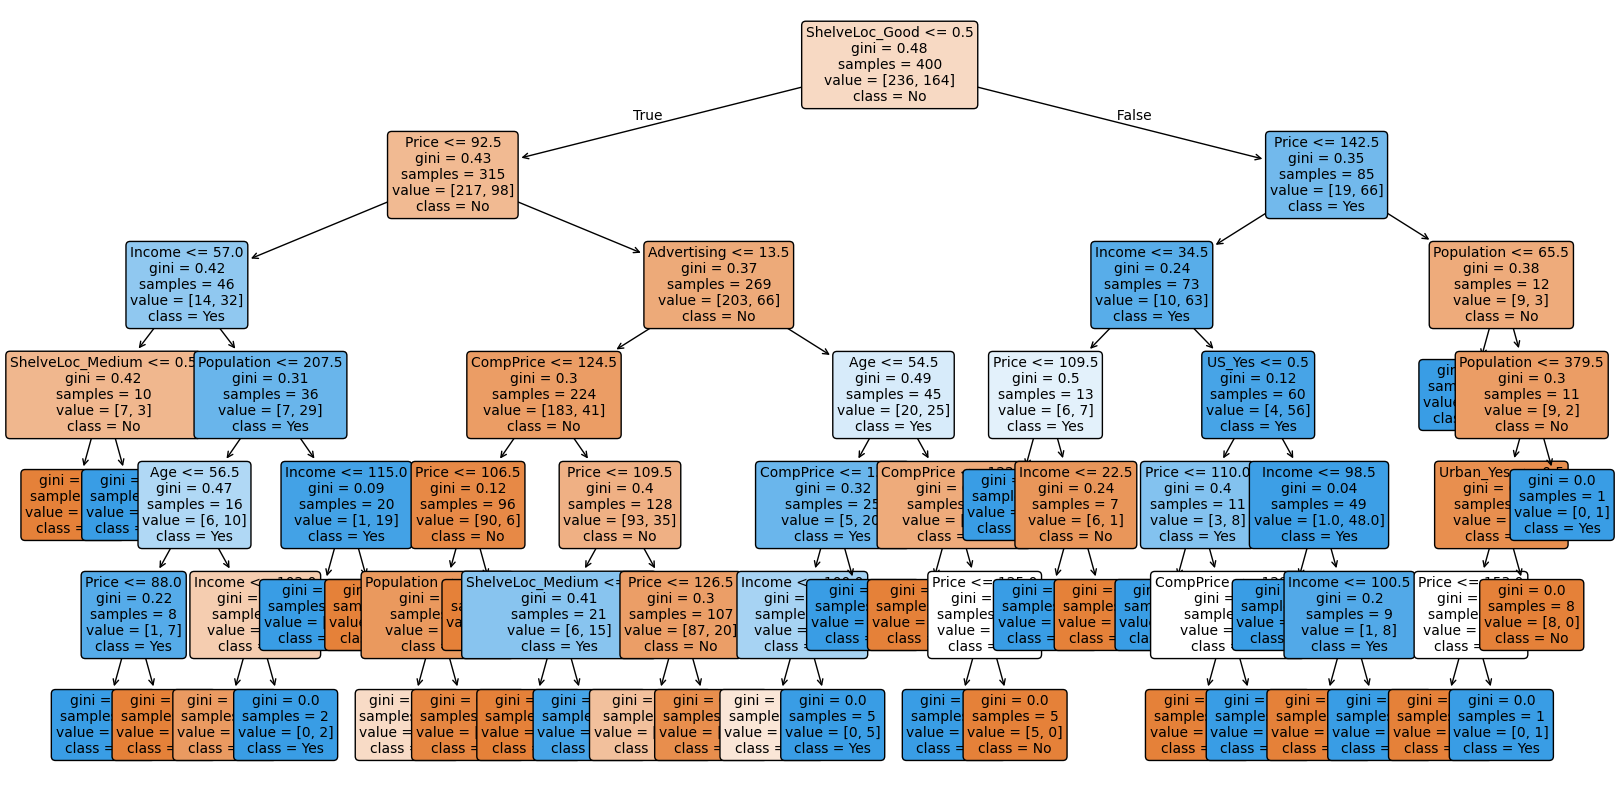

In [29]:
# Visualization
plt.figure(figsize=(20, 10), dpi=100) # Increased width and resolution

plot_tree(clf, 
          feature_names=X.columns, 
          class_names=['No', 'Yes'], 
          filled=True, 
          rounded=True,      # Rounds the corners of the boxes
          fontsize=10,       # Manually set font size to prevent overlapping
          precision=2)       # Limits decimals to 2 places to save space

plt.show()

Similar to other sklearn setups, we can use the `.predict()` function to obtain predictions for test data. We show code below to perform a test set evaluation, using `train_test_split()` to create training and test data.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)

clf_train = DecisionTreeClassifier(random_state=1)
clf_train.fit(X_train, y_train)
y_pred = clf_train.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.3f}")

Confusion Matrix:
[[86 33]
 [32 49]]

Accuracy: 0.675


We now prune the tree. We can use `cost_complexity_pruning_path()` to obtain the cost-complexity penalty parameter applied to each additional leaf. Suppose we have a large tree $T_0$ for our tree model, and want to prune it to a subtree. The cost complexity parameter $\alpha$ affects a subtree $T$ as follows:

$$R_\alpha(T) = R(T) + \alpha|T|$$

where $R(T)$ is the loss function for the tree model (for regression trees, usually residual sum of squares, for classification trees, usually some impurity metric like Gini coefficient), and $|T|$ is the number of leaves in $T$. Thus, $\alpha$ acts as a "tax" on every additional leaf we add to the tree. The chosen $T \subseteq T_0$ for the model is the minimizer of $R_\alpha(T)$.

In [31]:
# Get the pruning path
path = clf_train.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

To find the optimal size, we use a cross-validated grid search to find the optimal cost complexity.

In [32]:
from sklearn.model_selection import GridSearchCV

# Setup the grid search
param_grid = {'ccp_alpha': ccp_alphas}
grid = GridSearchCV(DecisionTreeClassifier(random_state=1), 
                    param_grid, 
                    cv=5, 
                    scoring='accuracy')

grid.fit(X_train, y_train)

best_alpha = grid.best_params_['ccp_alpha']
print(f"Best Alpha (k): {best_alpha:.4f}")

Best Alpha (k): 0.0128


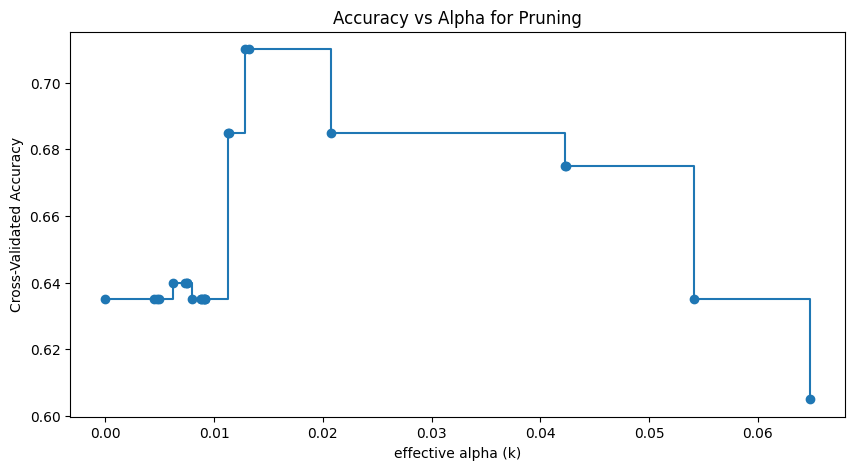

In [33]:
results = grid.cv_results_
plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas, results['mean_test_score'], marker='o', drawstyle="steps-post")
plt.xlabel("effective alpha (k)")
plt.ylabel("Cross-Validated Accuracy")
plt.title("Accuracy vs Alpha for Pruning")
plt.show()

Pruned Tree Confusion Matrix:
[[100  19]
 [ 36  45]]

Pruned Accuracy: 0.725


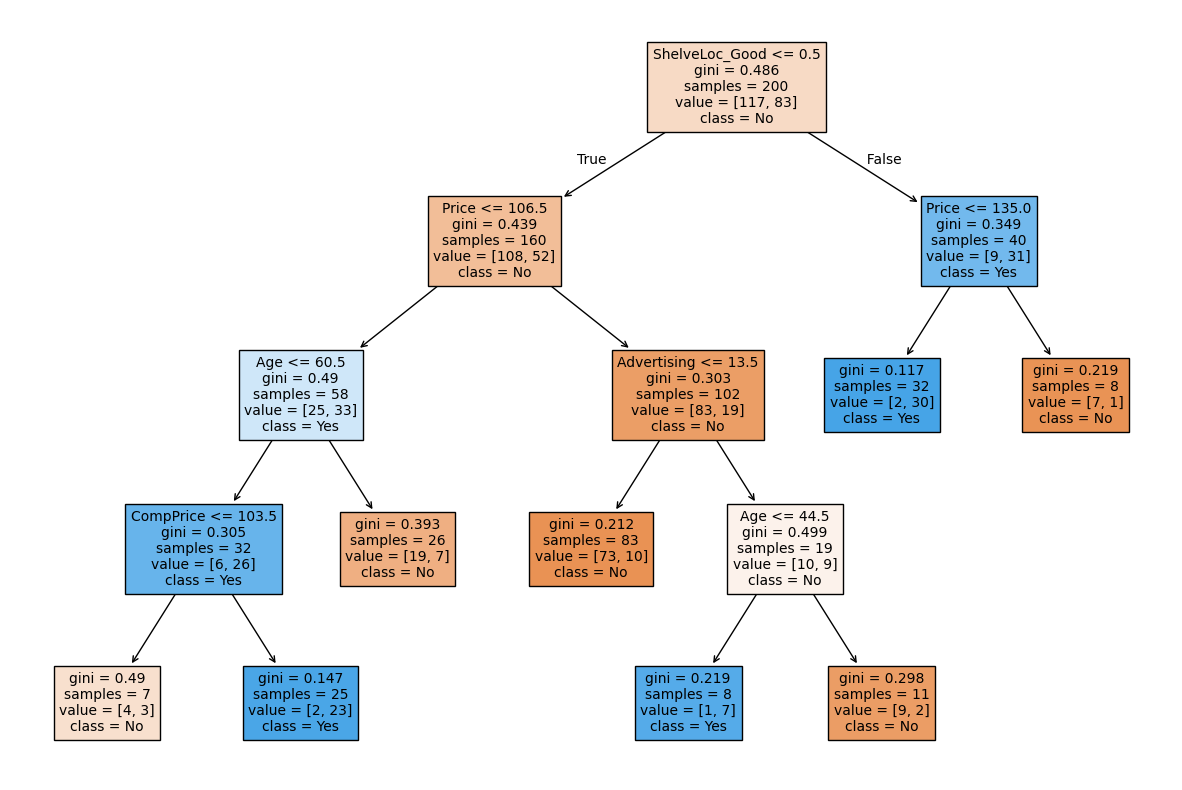

In [34]:
# Fit the pruned tree
pruned_clf = DecisionTreeClassifier(random_state=1, ccp_alpha=best_alpha)
pruned_clf.fit(X_train, y_train)

# Predict and compare
y_pred_pruned = pruned_clf.predict(X_test)

print("Pruned Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_pruned))
print(f"\nPruned Accuracy: {accuracy_score(y_test, y_pred_pruned):.3f}")

# Plot the pruned tree
plt.figure(figsize=(15, 10))
plot_tree(pruned_clf, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, fontsize=10)
plt.show()

### Regression Trees

We now use the decision tree to perform regression (instead of classification). Instead of a majority vote within a leaf, predictions are made by finding the mean y-variable value within a leaf's training samples.

We now demonstrate how to fit a regression tree to the `Boston` data set.

In [35]:
Boston = load_data('Boston')
Boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [36]:
X = Boston.drop('medv', axis=1)
y = Boston['medv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)

reg_tree = DecisionTreeRegressor(max_depth=3)
reg_tree.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

We can plot this tree as well, but these are no longer binary class bins (and are instead colored by a color gradient of the mean Y-value in each bin)

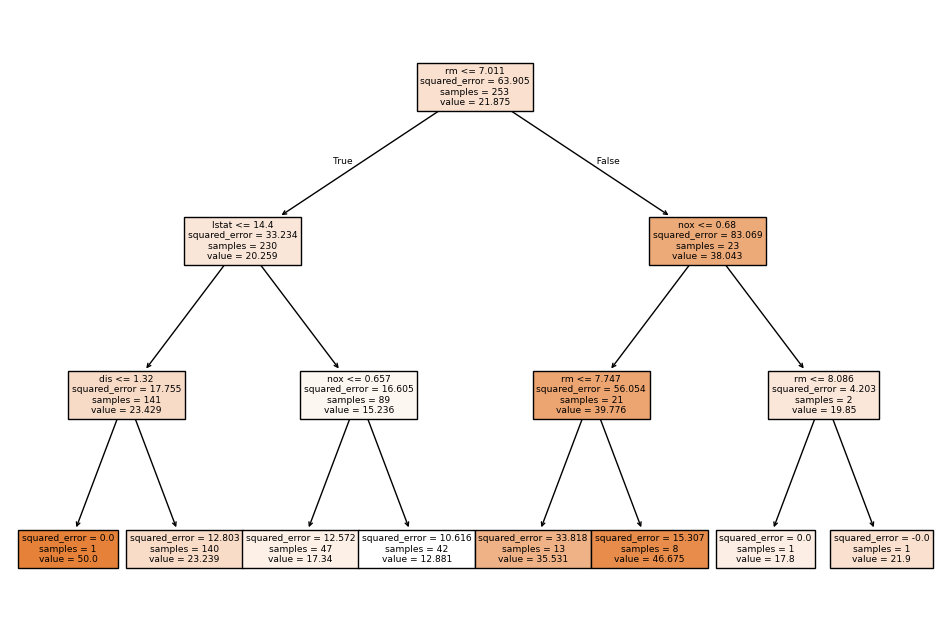

In [37]:
# Visualize
plt.figure(figsize=(12,8))
plot_tree(reg_tree, feature_names=X.columns, filled=True)
plt.show()

We can also evaluate the model (but using MSE instead of accuracy or other statistics obtained from the confusion matrix)

In [38]:
# MSE
y_hat = reg_tree.predict(X_test)
print(f"Test MSE: {mean_squared_error(y_test, y_hat):.3f}")

Test MSE: 31.505


### Bagging and Random Forests

While a single decision tree is a great tool for visually explaining unique categories of data, in regression especially, confining our predictions to unique leaf values' average of the y-variable can be quite limiting.

We can use *ensemble* methods instead, which rely on the collective predictive power of a group of many weaker learners rather than one slightly stronger individual learner. These approaches lower variance compared to using a single tree. A visual way to think about it is to imagine a decision tree where we only have one x-variable. Then, a decision tree regression amounts to creating a step function, where unique intervals of the x-variable correspond to unique leaves of the tree (and therefore, different y-variable predictions). If we instead create many different decision trees, averaging them out will minimize the limitations of confining our prediction function to a single "step function".

How do we create an ensemble of trees? Most simply, we can create bootstrapped datasets and fit a unique tree to each. This method is called **B**ootstrap **Ag**gregation (**BAG**ging).

An intuitive way to understand why the bootstrap algorithm can be powerful is to think of the following:
Suppose we have samples $x_1,...,x_n \sim F_X(x)$, for some distribution $F_X$, and then calculate a test statistic $T = g(x_1,...,x_n)$. Now, we want to estimate the distribution of $T$.

If we do not know the functional form of the distribution function $F_X$, we are resorted to using the empirical CDF $\hat{F}_X$ as a plug-in estimator for the distribution function. Instead of having the following process for generating a unique $T$:
1. Draw $x_1,...,x_n \sim F_X(x)$
2. Calculate $T = g(x_1,...,x_n)$

We instead can do the following:
1. Draw $x^*_1,...,x^*_n \sim \hat{F}_X(x)$
2. Calculate $T^* = g(x^*_1,...,x^*_n)$

The bootstrap repeats the latter procedure many times. This approach is quite elegant because it bypasses the need to directly estimate the distribution of $T$ (which requires using the change of variables formula involving $g$) when $g$ is non-parametric or "messy", such as the case when $g$ is based on the recursive splits of a decision tree.

In Bagging, we aren't just interested in the distribution of $T$; we use this "Bootstrap World" to generate a variety of likely scenarios. By averaging the results, we reduce the variance of our final model without needing to know the exact physics of the underlying population.

A random forest goes a step further to create a diverse set of trees (to further reduce the covariance between trees, as bootstrapped datasets will be highly correlated). In addition to fitting unique trees on unique bootstrapped datasets, the random forest also adds randomness to which variables are considered: at each split of any tree, the random forest algorithm considers only a random subset of all x-variables (rather than all x-variables) for finding the next optimal split.

In Python, both bagging and random forests handled by `RandomForestRegressor()`. Bagging is simply a Random Forest where `max_features` equals the total number of features.

In [39]:
from sklearn.ensemble import RandomForestRegressor

# Bagging (max_features = total number of features, which is 12 here)
bag_boston = RandomForestRegressor(max_features=12, random_state=1)
bag_boston.fit(X_train, y_train)

y_hat_bag = bag_boston.predict(X_test)
print(f"Bagging Test MSE: {mean_squared_error(y_test, y_hat_bag):.3f}")

Bagging Test MSE: 14.137


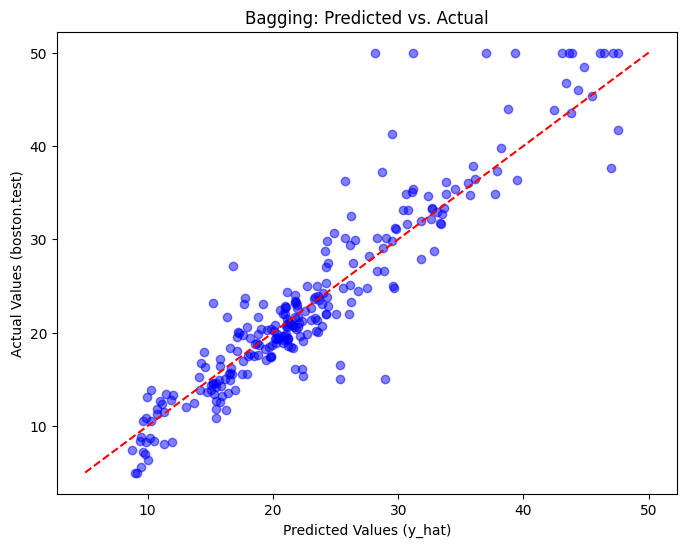

In [40]:
# 3. Plot Predicted vs. Actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_hat_bag, y_test, alpha=0.5, color='blue')

# Add the y=x line (abline(0,1) equivalent)
max_val = max(y_test.max(), y_hat_bag.max())
min_val = min(y_test.min(), y_hat_bag.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('Predicted Values (y_hat)')
plt.ylabel('Actual Values (boston.test)')
plt.title('Bagging: Predicted vs. Actual')
plt.show()

Let's try the same but for a random forest 

In [41]:
# Random Forest (m approx sqrt(p) or p/3. Let's try 6 as in the R lab)
rf_boston = RandomForestRegressor(max_features=6, random_state=1)
rf_boston.fit(X_train, y_train)

y_hat_rf = rf_boston.predict(X_test)
print(f"Random Forest Test MSE: {mean_squared_error(y_test, y_hat_rf):.3f}")

Random Forest Test MSE: 14.571


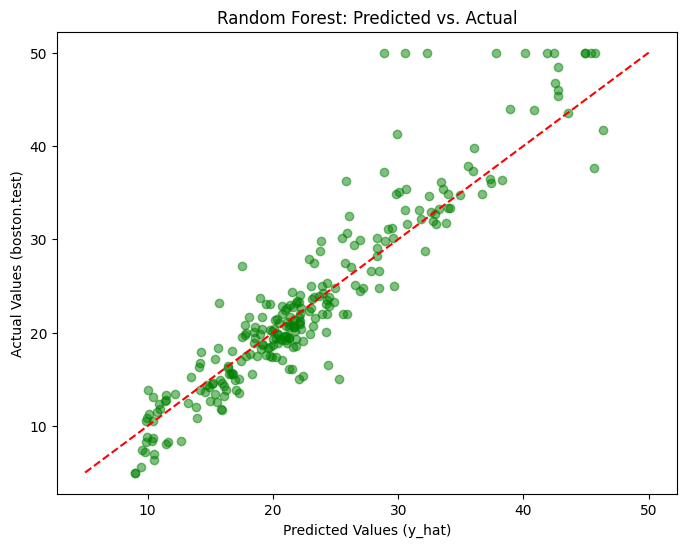

In [42]:
# 3. Plot Predicted vs. Actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_hat_rf, y_test, alpha=0.5, color='green')

# Add the y=x line
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('Predicted Values (y_hat)')
plt.ylabel('Actual Values (boston.test)')
plt.title('Random Forest: Predicted vs. Actual')
plt.show()

To see variable importances in a random forest, we can use the `.feature_importances_` attribute of a random forest object

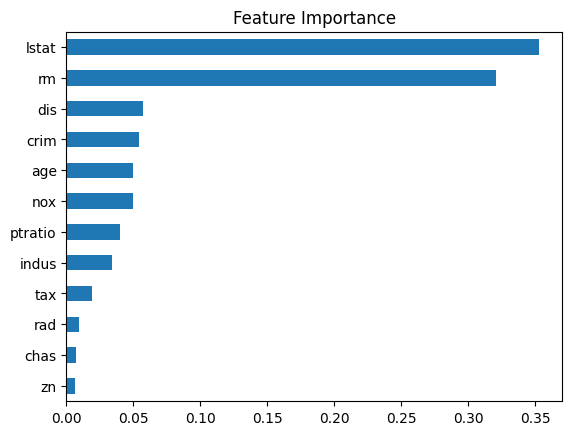

In [43]:
# Feature Importance
importances = pd.Series(rf_boston.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

### Boosting

Another way to create an ensemble of trees is through gradient boosting. This approach is even more direct in building a de-correlated set of trees. Trees are built sequentially on "residuals" $r_1,...,r_n$ for a dataset with $n$ observations, where the first tree is fit setting $r_i = y_i$, and then similar to gradient descent, $r_i \leftarrow r_i - \lambda\hat{f}^{(b)}(x_i)$ for subsequent trees, where $\hat{f}^{(b)}$ is the decision tree fitted at iteration $b$, and $\lambda$ is the step size. This makes each new tree focus on the portion of $y_i$ that was not explained by previous trees.

We use `GradientBoostingRegressor` for a gradient-boosted tree model. The `learning_rate` argument specifies the step size $\lambda$.

In [44]:
from sklearn.ensemble import GradientBoostingRegressor

boost_boston = GradientBoostingRegressor(n_estimators=5000, learning_rate=0.01, 
                                          max_depth=4, random_state=1)
boost_boston.fit(X_train, y_train)

y_hat_boost = boost_boston.predict(X_test)
print(f"Boosting Test MSE: {mean_squared_error(y_test, y_hat_boost):.3f}")

Boosting Test MSE: 11.843


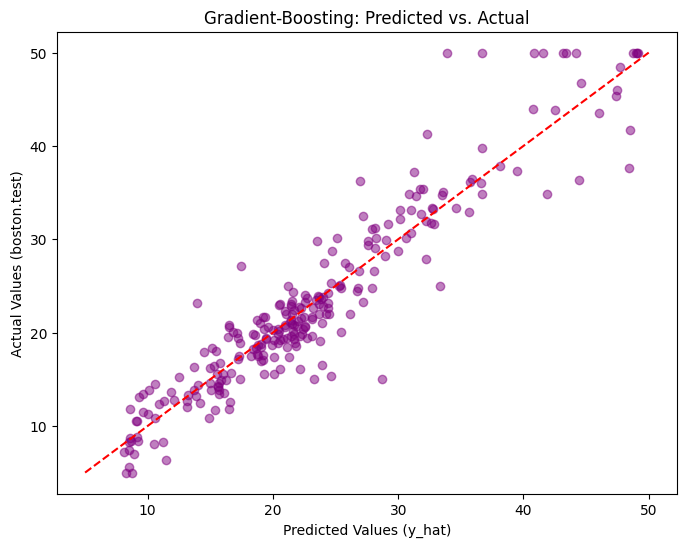

In [45]:
# Plot Predicted vs. Actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_hat_boost, y_test, alpha=0.5, color='purple')

# Add the y=x line
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('Predicted Values (y_hat)')
plt.ylabel('Actual Values (boston.test)')
plt.title('Gradient-Boosting: Predicted vs. Actual')
plt.show()

We can also see how the training error decreases with the `train_score_attribute`. To get an idea of how the test error decreases we can use the `staged_predict()` method to get the predicted values along the path.

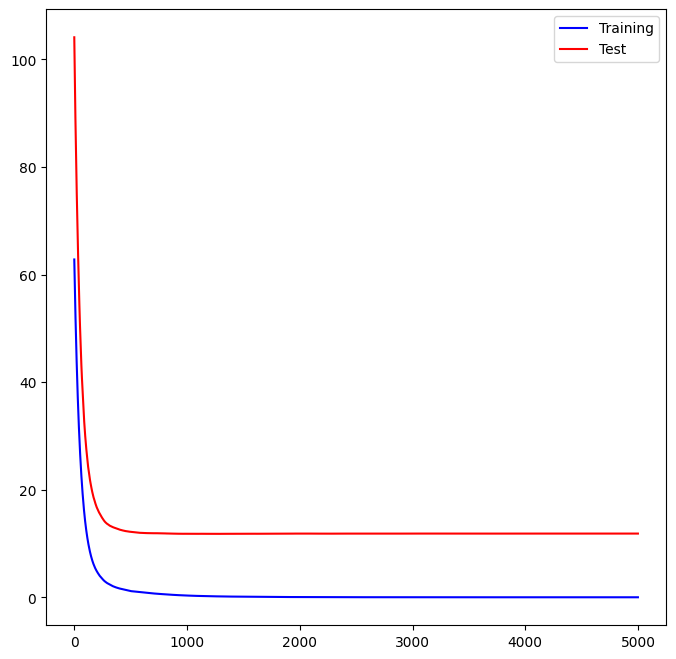

In [46]:
test_error = np.zeros_like(boost_boston.train_score_)
for idx, y_ in enumerate(boost_boston.staged_predict(X_test)):
   test_error[idx] = np.mean((y_test - y_)**2)

plot_idx = np.arange(boost_boston.train_score_.shape[0])
ax = subplots(figsize=(8,8))[1]
ax.plot(plot_idx,
        boost_boston.train_score_,
        'b',
        label='Training')
ax.plot(plot_idx,
        test_error,
        'r',
        label='Test')
ax.legend();

We can also play around with the step size by changing `learning_rate` argument. This parameter can also be tuned, but we do not do so here.

In [47]:
from sklearn.ensemble import GradientBoostingRegressor

# 1. Fit the model with a higher learning_rate (shrinkage=0.2)
# interaction.depth in R is roughly equivalent to max_depth in Python
boost_boston_02 = GradientBoostingRegressor(n_estimators=5000, 
                                              learning_rate=0.2, 
                                              max_depth=4, 
                                              random_state=1)
boost_boston_02.fit(X_train, y_train)

# 2. Predict the test data
y_hat_boost_02 = boost_boston_02.predict(X_test)

# 3. Compute Test MSE
mse_boost_02 = mean_squared_error(y_test, y_hat_boost_02)
print(f"Boosting (Learning Rate 0.2) Test MSE: {mse_boost_02:.3f}")

Boosting (Learning Rate 0.2) Test MSE: 11.697


In [48]:
results = {
    "Method": [
        "Decision Tree",
        "Bagging",
        "Random Forest",
        "Boosting",
        "Boosting (Learning Rate 0.2)"
    ],
    "Test MSE": [
        mean_squared_error(y_test, y_hat),
        mean_squared_error(y_test, y_hat_bag),
        mean_squared_error(y_test, y_hat_rf),
        mean_squared_error(y_test, y_hat_boost),
        mse_boost_02
    ]
}

df_results = pd.DataFrame(results)

# Format the MSE to 3 decimal places for a cleaner look
df_results["Test MSE"] = df_results["Test MSE"].map("{:.3f}".format)

# Display the table
df_results.head()

,Method,Test MSE
0,Decision Tree,31.505
1,Bagging,14.137
2,Random Forest,14.571
3,Boosting,11.843
4,Boosting (Learning Rate 0.2),11.697
